[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/takechanman1228/marketing-science-in-python/blob/main/notebooks/part3-causal-inference/sec3.2_ab_test_figures.ipynb)

# §3.2 "A/B Test Design" — code & figures

Companion code for **§3.2** of *Marketing Science in Python*. It runs every
worked snippet shown in the chapter — the opening two-proportion z-test, the
sample-size calculation, and a full CUPED simulation — and builds the two
conceptual figures the chapter embeds, writing each to `images/part3/sec3.2/`:

- `power_concept.png` — statistical power: H0 / H1 distributions with the
  alpha, beta, and power (1−beta) regions.
- `sample_size_sensitivity.png` — required sample size per group vs. MDE
  (halving the MDE roughly quadruples the sample).

The charts are illustrative, drawn from formulas; the CUPED section uses a
small simulated dataset generated inline. The chapter's third figure,
`cuped_how_it_works.png`, is a hand-designed infographic and is not generated
here.

### Setup

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize, proportions_ztest

save_dir = os.path.join('..', '..', 'images', 'part3', 'sec3.2')
os.makedirs(save_dir, exist_ok=True)

plt.rcParams.update({'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})

## Is the result significant? — two-proportion z-test

The chapter opens with a two-week checkout test: 127/5,000 conversions in
treatment vs. 115/5,000 in control. A small +0.24-point lift, but is it
distinguishable from noise? A two-proportion z-test gives the p-value.

In [2]:
conversions = np.array([127, 115])   # treatment, control
users = np.array([5000, 5000])
stat, p_value = proportions_ztest(conversions, users, alternative="two-sided")
print(f"p-value: {p_value:.2f}")     # 0.43 — cannot separate the lift from noise

p-value: 0.43


## Figure 1 — Statistical power (H0 vs H1)

Two distributions of the test statistic: under the null (H0, no effect) it is
centered at 0; under the alternative (H1, a real effect) it is shifted right.
The critical value $z_{1-\alpha/2}$ splits each curve. The right tail of H0
beyond the critical value is $\alpha/2$ (false positives — the two-sided test
splits $\alpha$ across both tails); the part of H1 below the critical value is
$\beta$ (missed effects); the part of H1 above it is the **power**, $1-\beta$.

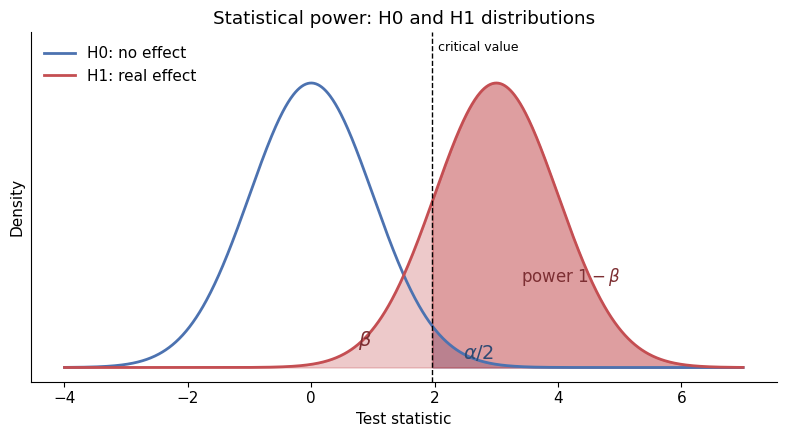

In [3]:
z_crit = stats.norm.ppf(0.975)  # ~1.96, two-sided alpha = 0.05
effect = 3.0                    # shift of H1 (in SE units), chosen for ~80% power
x = np.linspace(-4, 4 + effect, 1000)
h0 = stats.norm.pdf(x, loc=0, scale=1)
h1 = stats.norm.pdf(x, loc=effect, scale=1)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(x, h0, color='#4C72B0', lw=2, label='H0: no effect')
ax.plot(x, h1, color='#C44E52', lw=2, label='H1: real effect')

# alpha/2: H0 right tail beyond the critical value (two-sided test)
mask_a = x >= z_crit
ax.fill_between(x[mask_a], 0, h0[mask_a], color='#4C72B0', alpha=0.45)
# beta: H1 below the critical value
mask_b = x <= z_crit
ax.fill_between(x[mask_b], 0, h1[mask_b], color='#C44E52', alpha=0.30)
# power (1 - beta): H1 above the critical value
mask_p = x >= z_crit
ax.fill_between(x[mask_p], 0, h1[mask_p], color='#C44E52', alpha=0.55)

ax.axvline(z_crit, color='black', ls='--', lw=1)
ax.annotate('critical value', xy=(z_crit, 0.41), xytext=(z_crit + 0.1, 0.44),
            fontsize=9, va='bottom')
ax.annotate(r'$\alpha/2$', xy=(z_crit + 0.5, 0.012), fontsize=14, color='#2f4a73')
ax.annotate(r'$\beta$', xy=(z_crit - 1.2, 0.03), fontsize=14, color='#7d2f33')
ax.annotate(r'power $1-\beta$', xy=(effect + 0.4, 0.12), fontsize=12, color='#7d2f33')

ax.set_xlabel('Test statistic')
ax.set_ylabel('Density')
ax.set_yticks([])
ax.set_ylim(top=0.47)
ax.set_title('Statistical power: H0 and H1 distributions')
ax.legend(loc='upper left', frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(save_dir, 'power_concept.png'), dpi=150, bbox_inches='tight')

## Sample size for a target MDE

How many users per group to detect a 0.5-point lift from a 2% baseline at
$\alpha = 0.05$ and 80% power? `proportion_effectsize` converts the two rates
into the effect size statsmodels expects, and `solve_power` solves for `n`.

In [4]:
baseline_cvr = 0.02
target_cvr = 0.025
effect_size = abs(proportion_effectsize(target_cvr, baseline_cvr))

analysis = NormalIndPower()
required_n = analysis.solve_power(
    effect_size=effect_size,
    alpha=0.05,
    power=0.80,
    ratio=1,
    alternative="two-sided",
)
print(f"Required sample size per group: {required_n:.0f}")  # ~13,800

Required sample size per group: 13768


## Figure 2 — Sample size sensitivity

Required sample size per group as a function of the Minimum Detectable Effect
(MDE), for a two-sample proportions test at a 2% baseline, $\alpha = 0.05$,
power $= 0.80$. Because $n \propto 1/\delta^2$, halving the MDE roughly
quadruples the required sample.

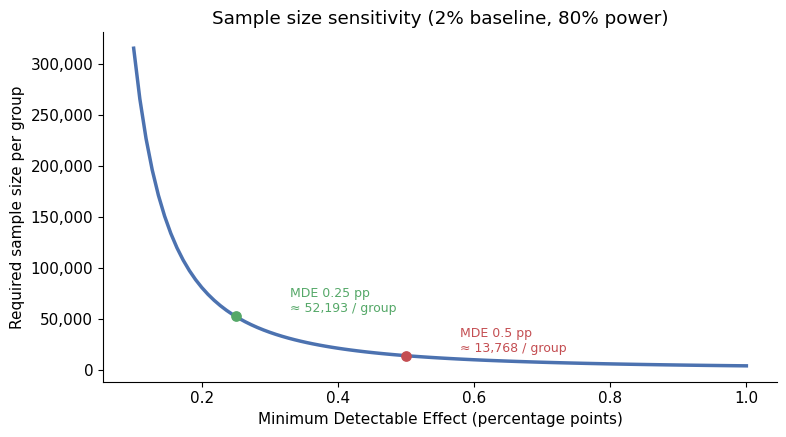

In [5]:
p0 = 0.02
analysis = NormalIndPower()

mde_pp = np.linspace(0.1, 1.0, 100)          # MDE in percentage points
n_required = []
for d in mde_pp:
    es = proportion_effectsize(p0, p0 + d / 100)
    n = analysis.solve_power(effect_size=es, alpha=0.05, power=0.80, ratio=1,
                             alternative='two-sided')
    n_required.append(n)
n_required = np.array(n_required)


def n_at(mde):
    es = proportion_effectsize(p0, p0 + mde / 100)
    return analysis.solve_power(effect_size=es, alpha=0.05, power=0.80, ratio=1,
                                alternative='two-sided')


fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(mde_pp, n_required, color='#4C72B0', lw=2.5)

for mde, color in [(0.5, '#C44E52'), (0.25, '#55A868')]:
    n = n_at(mde)
    ax.scatter([mde], [n], color=color, zorder=5, s=45)
    ax.annotate(f'MDE {mde} pp\n≈ {n:,.0f} / group', xy=(mde, n),
                xytext=(mde + 0.08, n + 4000), fontsize=9, color=color)

ax.set_xlabel('Minimum Detectable Effect (percentage points)')
ax.set_ylabel('Required sample size per group')
ax.set_title('Sample size sensitivity (2% baseline, 80% power)')
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f}'))
fig.tight_layout()
fig.savefig(os.path.join(save_dir, 'sample_size_sensitivity.png'), dpi=150, bbox_inches='tight')

## CUPED — variance reduction from pre-experiment data

A simulated coupon campaign where each customer has a natural spending
tendency. That tendency drives spend both *before* and *during* the campaign,
so the two are correlated (~0.75 here). CUPED subtracts the predictable,
pre-experiment part of each customer's outcome, shrinking the standard error
of the measured lift without biasing it. The true lift is set to $1.20.

In [6]:
rng = np.random.default_rng(8)

n_per_group = 5_000
true_lift = 1.20

n = 2 * n_per_group

# Some customers naturally spend more than others.
customer_tendency = rng.gamma(shape=4, scale=12, size=n)

# Spend before the campaign.
pre_spend = customer_tendency + rng.normal(loc=0, scale=14, size=n)
pre_spend = np.clip(pre_spend, 0, None)

# Randomly assign customers to control or treatment.
treatment = np.repeat([0, 1], n_per_group)
rng.shuffle(treatment)

# Spend during the campaign.
campaign_spend = (
    customer_tendency
    + true_lift * treatment
    + rng.normal(loc=0, scale=14, size=n)
)
campaign_spend = np.clip(campaign_spend, 0, None)

df = pd.DataFrame({
    "treatment": treatment,
    "pre_spend": pre_spend,
    "campaign_spend": campaign_spend,
})

# CUPED adjustment.
theta = (
    np.cov(df["campaign_spend"], df["pre_spend"], ddof=1)[0, 1]
    / np.var(df["pre_spend"], ddof=1)
)

df["cuped_spend"] = (
    df["campaign_spend"]
    - theta * (df["pre_spend"] - df["pre_spend"].mean())
)


def ab_summary(data, metric):
    control = data.loc[data["treatment"] == 0, metric]
    treatment = data.loc[data["treatment"] == 1, metric]

    lift = treatment.mean() - control.mean()

    standard_error = np.sqrt(
        treatment.var(ddof=1) / len(treatment)
        + control.var(ddof=1) / len(control)
    )

    test = stats.ttest_ind(treatment, control, equal_var=False)

    return pd.Series({
        "lift": lift,
        "standard_error": standard_error,
        "p_value": test.pvalue,
        "ci_low": lift - 1.96 * standard_error,
        "ci_high": lift + 1.96 * standard_error,
    })


results = pd.DataFrame({
    "Raw campaign spend": ab_summary(df, "campaign_spend"),
    "CUPED adjusted spend": ab_summary(df, "cuped_spend"),
}).T

se_reduction = (
    1
    - results.loc["CUPED adjusted spend", "standard_error"]
    / results.loc["Raw campaign spend", "standard_error"]
)

variance_reduction = 1 - (1 - se_reduction) ** 2

print(
    "Correlation between pre spend and campaign spend:",
    round(df["pre_spend"].corr(df["campaign_spend"]), 2),
)

print("Theta:", round(theta, 2))
print(results.round(3))

print(f"\nStandard error reduction: {se_reduction:.1%}")
print(f"Variance reduction: {variance_reduction:.1%}")

Correlation between pre spend and campaign spend: 0.75
Theta: 0.75
                       lift  standard_error  p_value  ci_low  ci_high
Raw campaign spend    0.969           0.549    0.078  -0.107    2.045
CUPED adjusted spend  1.065           0.364    0.003   0.352    1.779

Standard error reduction: 33.7%
Variance reduction: 56.1%


In [7]:
print('Saved figures to', save_dir)

Saved figures to ../../images/part3/sec3.2
